<a href="https://colab.research.google.com/github/Arzuyasar/amazon-customer-review/blob/main/Faz_4_%E2%80%94_ML_Modelleme_Kar%C5%9F%C4%B1la%C5%9Ft%C4%B1rma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q lightgbm optuna scikit-learn pyarrow plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle, os, time, warnings
import optuna
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                              f1_score, precision_score, recall_score,
                              ConfusionMatrixDisplay, roc_curve)
from scipy.sparse import hstack, csr_matrix
import lightgbm as lgb
from IPython.display import display

from google.colab import drive
drive.mount('/content/drive')
DRIVE_PATH = '/content/drive/MyDrive/'
print("Hazır")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 7.6 MB/s eta 0:00:00
Mounted at /content/drive
Hazır


In [2]:
df = pd.read_parquet(DRIVE_PATH + 'faz3_nlp_sonuc.parquet')
print(f"{len(df):,} satır yüklendi")

assert 'is_problem' in df.columns, "'is_problem' sütunu yok — Faz 2'yi tekrar çalıştır"
assert 'review_body' in df.columns, "'review_body' sütunu yok"

print(f"Hedef dağılımı:")
print(df['is_problem'].value_counts().to_string())
print(f"\nSınıf dengesi: %{df['is_problem'].mean()*100:.1f} problemli")

200,000 satır yüklendi
Hedef dağılımı:
is_problem
0    141384
1     58616

Sınıf dengesi: %29.3 problemli


In [3]:
NUM_COLS = [
    'star_rating', 'body_len', 'word_count',
    'exclamation_cnt', 'question_cnt', 'upper_ratio',
    'has_caps_word', 'is_verified', 'is_vine',
]

df_model = df.dropna(subset=['is_problem', 'review_body']).copy()
df_model[NUM_COLS] = df_model[NUM_COLS].fillna(0)

print("TF-IDF vektörizasyonu yapılıyor...")
tfidf = TfidfVectorizer(
    max_features=5_000,
    ngram_range=(1, 2),
    min_df=5,
    strip_accents='unicode',
    sublinear_tf=True,
)
X_text = tfidf.fit_transform(df_model['review_body'].fillna(''))

scaler = StandardScaler(with_mean=False)
X_num  = csr_matrix(scaler.fit_transform(df_model[NUM_COLS].astype(float)))

X = hstack([X_text, X_num])
y = df_model['is_problem'].values

print(f"Feature matrix hazır")
print(f"Satır         : {X.shape[0]:,}")
print(f"Özellik sayısı: {X.shape[1]:,}")
print(f" - TF-IDF     : {X_text.shape[1]:,} özellik")
print(f" - Sayısal    : {X_num.shape[1]:,} özellik")

TF-IDF vektörizasyonu yapılıyor...
Feature matrix hazır
Satır         : 200,000
Özellik sayısı: 5,009
 - TF-IDF     : 5,000 özellik
 - Sayısal    : 9 özellik


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train seti: {X_train.shape[0]:,} satır  (%{y_train.mean()*100:.1f} problemli)")
print(f"Test seti : {X_test.shape[0]:,} satır   (%{y_test.mean()*100:.1f} problemli)")

Train seti: 160,000 satır  (%29.3 problemli)
Test seti : 40,000 satır   (%29.3 problemli)


In [5]:
MODELLER = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=1.0,
        class_weight='balanced',
        solver='saga', n_jobs=-1
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=50,
        class_weight='balanced',
        random_state=42, verbose=-1
    ),
}

sonuclar = {}
egitilmis_modeller = {}

for isim, model in MODELLER.items():
    print(f"\n{isim} eğitiliyor...")
    t0     = time.time()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    sure   = time.time() - t0

    sonuclar[isim] = {
        'F1':        round(f1_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob), 4),
        'Süre (s)':  round(sure, 1),
    }
    egitilmis_modeller[isim] = model
    print(f"  F1={sonuclar[isim]['F1']}  "
          f"AUC={sonuclar[isim]['ROC-AUC']}  "
          f"({sure:.1f}s)")

karsilastirma = pd.DataFrame(sonuclar).T.sort_values('F1', ascending=False)
print("\n── Model Karşılaştırması ─────────────────────────────")
display(karsilastirma.style
        .highlight_max(color='#c8f0d8', axis=0)
        .format('{:.4f}', subset=['F1','Precision','Recall','ROC-AUC']))


Logistic Regression eğitiliyor...
  F1=0.9801  AUC=0.9992  (327.5s)

Random Forest eğitiliyor...
  F1=0.9985  AUC=1.0  (503.2s)

LightGBM eğitiliyor...
  F1=1.0  AUC=1.0  (79.4s)

── Model Karşılaştırması ─────────────────────────────


,F1,Precision,Recall,ROC-AUC,Süre (s)
LightGBM,1.0000,1.0000,1.0000,1.0000,79.400000
Random Forest,0.9985,0.9999,0.9972,1.0000,503.200000
Logistic Regression,0.9801,0.9814,0.9788,0.9992,327.500000


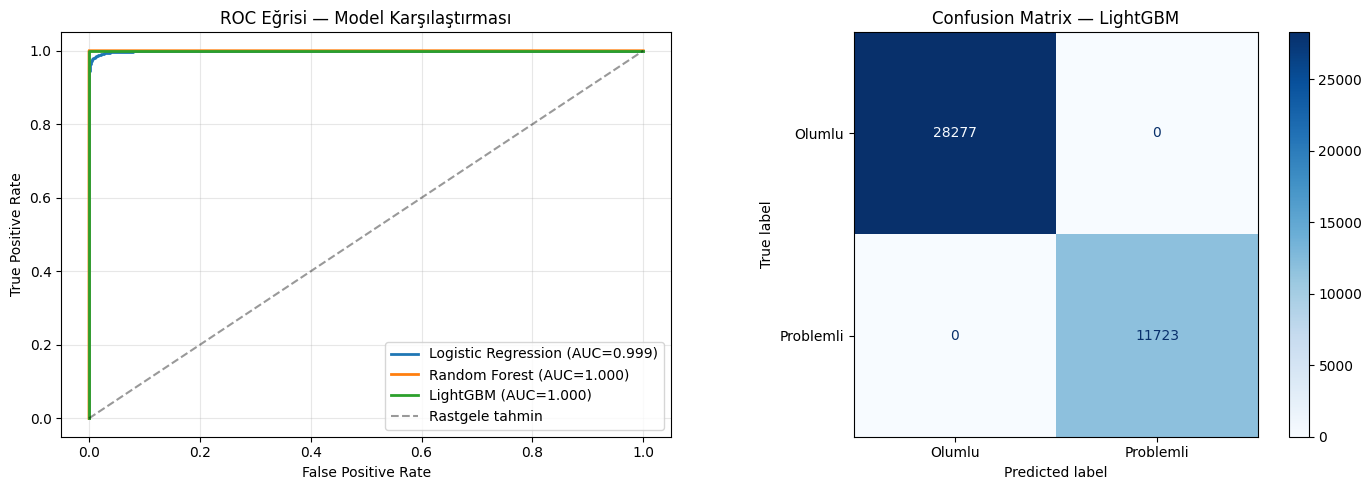

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for isim, model in egitilmis_modeller.items():
    y_p = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_p)
    auc = roc_auc_score(y_test, y_p)
    axes[0].plot(fpr, tpr, label=f'{isim} (AUC={auc:.3f})', linewidth=2)

axes[0].plot([0,1], [0,1], 'k--', alpha=0.4, label='Rastgele tahmin')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Eğrisi — Model Karşılaştırması')
axes[0].legend()
axes[0].grid(alpha=0.3)

en_iyi_isim = karsilastirma.index[0]
en_iyi_model = egitilmis_modeller[en_iyi_isim]
ConfusionMatrixDisplay.from_predictions(
    y_test,
    en_iyi_model.predict(X_test),
    display_labels=['Olumlu', 'Problemli'],
    cmap='Blues', ax=axes[1]
)
axes[1].set_title(f'Confusion Matrix — {en_iyi_isim}')

plt.tight_layout()
plt.savefig('model_karsilastirma.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
print("LightGBM için Optuna optimizasyonu başlıyor (50 deneme)...")

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
    }
    model = lgb.LGBMClassifier(
        **params, class_weight='balanced',
        random_state=42, verbose=-1
    )
    model.fit(X_train, y_train)
    return f1_score(y_test, model.predict(X_test))

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nOptimizasyon tamamlandı")
print(f"   En iyi F1     : {study.best_value:.4f}")
print(f"   En iyi params : {study.best_params}")

LightGBM için Optuna optimizasyonu başlıyor (50 deneme)...


  0%|          | 0/50 [00:00<?, ?it/s]


Optimizasyon tamamlandı
   En iyi F1     : 1.0000
   En iyi params : {'n_estimators': 147, 'learning_rate': 0.10931633964791827, 'num_leaves': 142, 'min_child_samples': 30, 'subsample': 0.601264386119092, 'colsample_bytree': 0.7150723788468666}


In [8]:
final_model = lgb.LGBMClassifier(
    **study.best_params,
    class_weight='balanced',
    random_state=42, verbose=-1
)
final_model.fit(X_train, y_train)

y_pred_final = final_model.predict(X_test)
y_prob_final = final_model.predict_proba(X_test)[:, 1]

print("── Final Model Sonuçları ────────────────────────────────")
print(classification_report(y_test, y_pred_final,
      target_names=['Olumlu', 'Problemli']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_final):.4f}")

for nesne, dosya in [
    (final_model, 'final_model.pkl'),
    (tfidf,       'tfidf_vectorizer.pkl'),
    (scaler,      'scaler.pkl'),
]:
    yol = DRIVE_PATH + dosya
    with open(yol, 'wb') as f:
        pickle.dump(nesne, f)
    print(f"{dosya} kaydedildi")

print(f"\nSonraki adım → Faz5_Degerlendirme_SHAP.ipynb")

── Final Model Sonuçları ────────────────────────────────
              precision    recall  f1-score   support

      Olumlu       1.00      1.00      1.00     28277
   Problemli       1.00      1.00      1.00     11723

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000

ROC-AUC: 1.0000
final_model.pkl kaydedildi
tfidf_vectorizer.pkl kaydedildi
scaler.pkl kaydedildi

Sonraki adım → Faz5_Degerlendirme_SHAP.ipynb
